# 导入类库

In [1]:
# 导入类库
import numpy as np
from numpy import arange
from matplotlib import pyplot
from pandas import read_csv

from pandas import  set_option
from pandas.plotting import scatter_matrix

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor

from sklearn.metrics import mean_squared_error

# 优化显示

In [2]:
# 优化
# 1.不显示错误警告
import warnings
warnings.filterwarnings('ignore')

# 2.画图过程中的中文显示
from matplotlib import pyplot as plt
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False     # 修复负号显示问题

# 导入数据
修改文件地址，无表头的做类似的修改表头的操作即可

In [3]:
# 导入数据
filename = 'housing.csv'
names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
         'RAD', 'TAX', 'PRTATIO', 'B', 'LSTAT', 'MEDV']
dataset = read_csv(filename, names=names, delim_whitespace=True)
# print(dataset)

# 查看数据

In [4]:
# 数据维度
print(dataset.shape)

# 特征熟悉的字段类型
print(dataset.dtypes)

# 查看最开始的30条记录
set_option('display.width',120)
print(dataset.head(30))

# 描述性统计信息
set_option('display.precision', 1)
print(dataset.describe())

# 关联关系
set_option('display.precision', 2)
print(dataset.corr(method='pearson'))

(506, 14)
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PRTATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object
       CRIM    ZN  INDUS  CHAS    NOX     RM    AGE     DIS  RAD    TAX  PRTATIO       B  LSTAT  MEDV
0   0.00632  18.0   2.31     0  0.538  6.575   65.2  4.0900    1  296.0     15.3  396.90   4.98  24.0
1   0.02731   0.0   7.07     0  0.469  6.421   78.9  4.9671    2  242.0     17.8  396.90   9.14  21.6
2   0.02729   0.0   7.07     0  0.469  7.185   61.1  4.9671    2  242.0     17.8  392.83   4.03  34.7
3   0.03237   0.0   2.18     0  0.458  6.998   45.8  6.0622    3  222.0     18.7  394.63   2.94  33.4
4   0.06905   0.0   2.18     0  0.458  7.147   54.2  6.0622    3  222.0     18.7  396.90   5.33  36.2
5   0.02985   0.0   2.18     0  0.458  6.430   58.7  6.0622    3  222.0     18.7  394.12   5.21  2

# 可视化查看数据
绘图报错的话，注意查看是否有文本列也参与了绘图

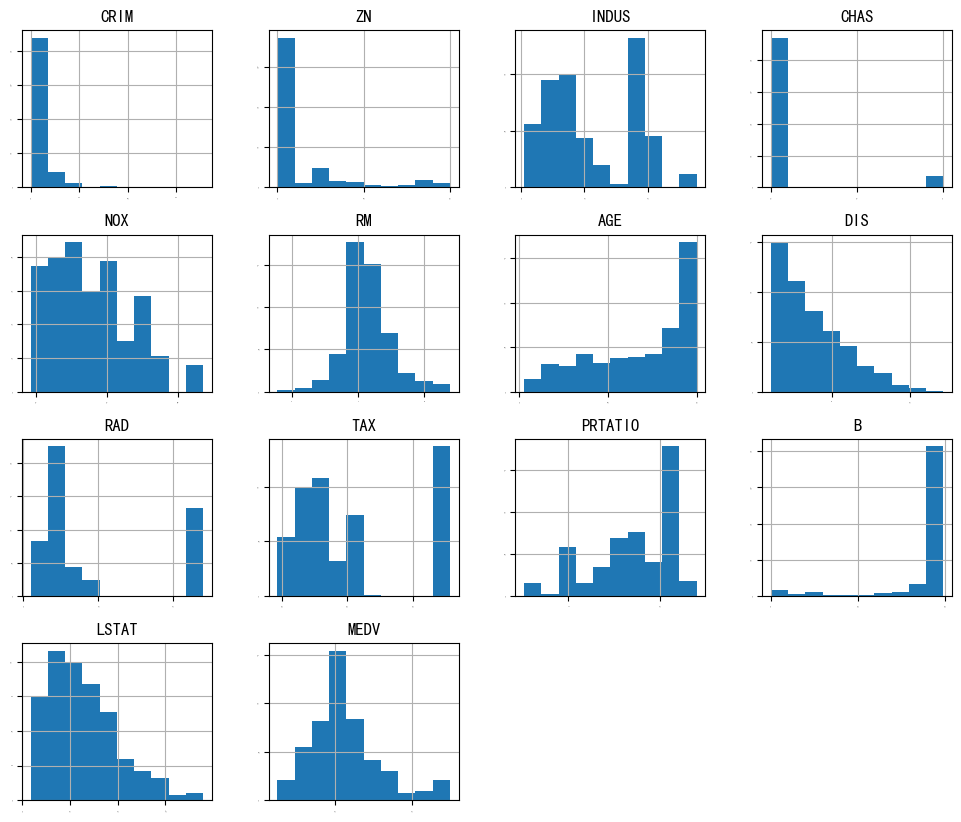

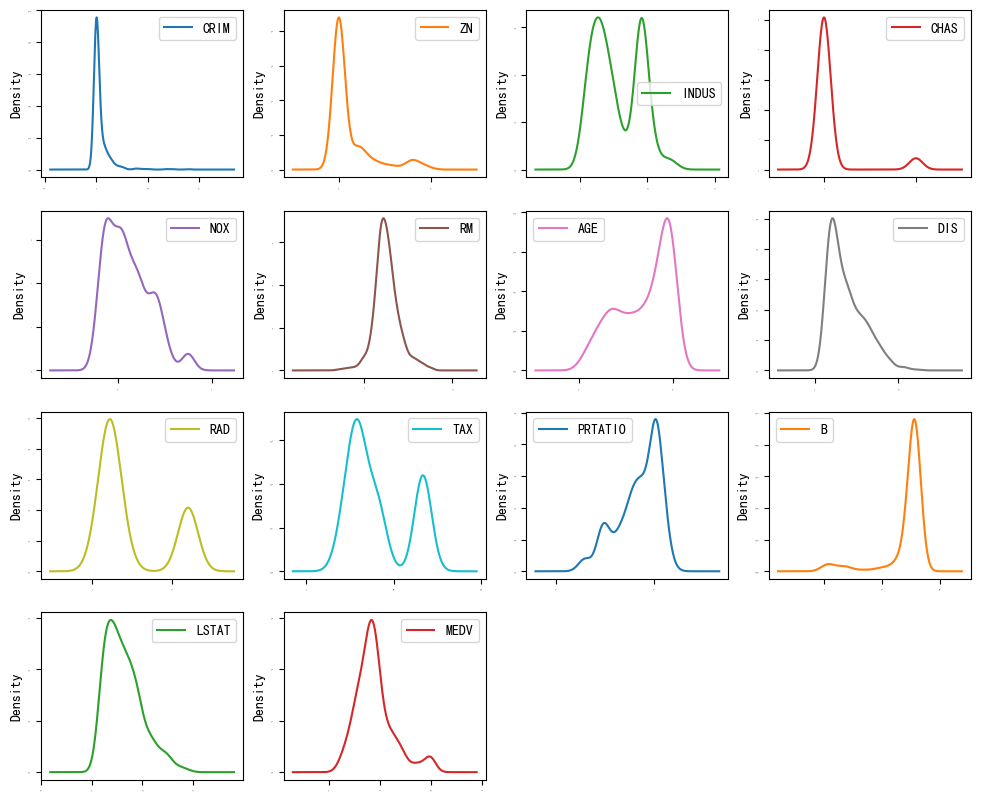

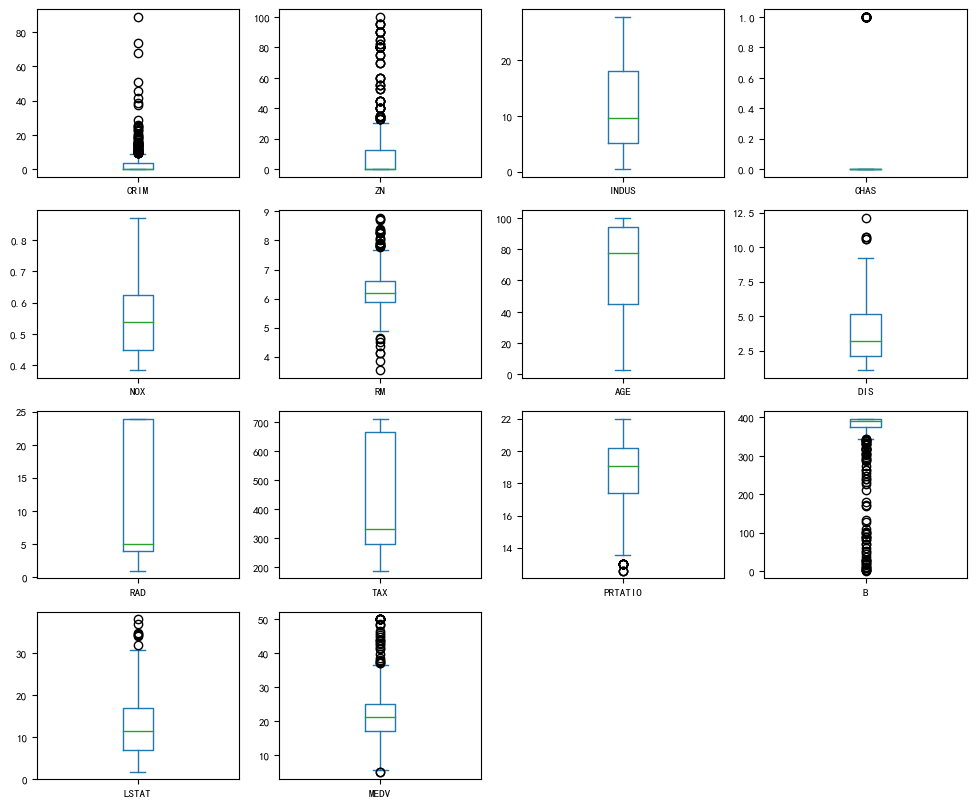

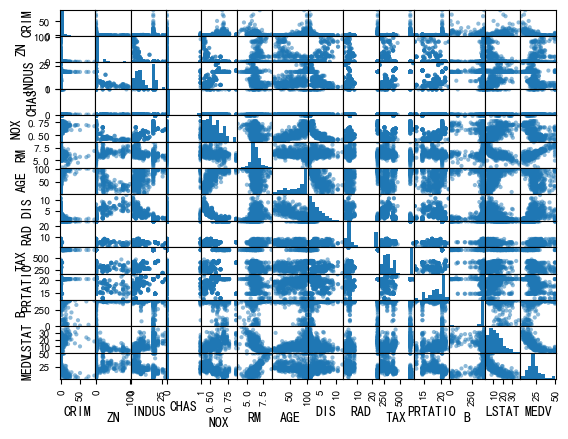

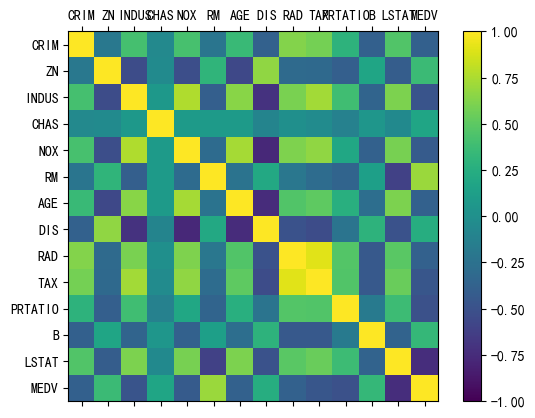

In [5]:
# 直方图
dataset.hist(sharex = False, figsize = (12, 10), sharey = False, xlabelsize = 1, ylabelsize = 1)
pyplot.show()

# 密度图
dataset.plot(kind = 'density', figsize = (12, 10), subplots = True, layout=(4, 4), sharex = False, fontsize = 1)
pyplot.show()

# 箱线图
dataset.plot(kind = 'box', figsize = (12, 10), subplots = True, layout = (4, 4), sharex = False, sharey = False, fontsize = 8)
pyplot.show()

# 散点矩阵图
scatter_matrix(dataset)
pyplot.show()

# 相关矩阵图
fig = pyplot.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(dataset.corr(), vmin = -1, vmax = 1, interpolation = 'none')
fig.colorbar(cax)
ticks = np.arange(0, 14, 1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(names)
ax.set_yticklabels(names)
pyplot.show()

# 分离数据集
分离X、Y，分离训练数据与测试数据；
设置交叉验证和评估参数

In [6]:
# 分离数据集
array = dataset.values
X = array[:, 0:13]
Y = array[:, 13]
validation_size = 0.2
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size = validation_size, random_state = seed)

# 评估算法 - 评估标准
num_folds = 10
seed = 7
scoring = 'neg_mean_squared_error'

# 单一算法
这里用了6种算法

LR: -22.006009 (12.188886)
LASSO: -27.105803 (13.165915)
EN: -27.923014 (13.156405)
KNN: -39.808936 (16.507968)
CART: -27.022382 (18.864710)
SVM: -67.824705 (32.801530)


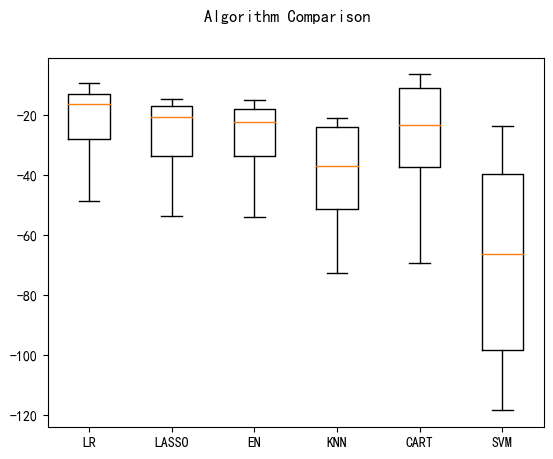

耗时(秒)： 0.9068899154663086


In [7]:
import time
start = time.time()

# 评估算法 - baseline
models = {}
models['LR']    = LinearRegression()
models['LASSO'] = Lasso()
models['EN']    = ElasticNet()
models['KNN']   = KNeighborsRegressor()
models['CART']  = DecisionTreeRegressor()
models['SVM']   = SVR()

# 评估算法
results = []
for key in models:
    kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
    cv_result = cross_val_score(models[key], X_train, Y_train, cv = kfold, scoring = scoring)
    results.append(cv_result)
    print('%s: %f (%f)' % (key, cv_result.mean(), cv_result.std()))
    
#评估算法 - 箱线图
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(models.keys())
pyplot.show()

finish = time.time()
print("耗时(秒)：", finish - start)

# 单一算法：优化
使用pipeline，添加对数据的处理

ScalerLR: -22.006009 (12.188886)
ScalerLASSO: -27.205896 (12.124418)
ScalerEN: -28.301160 (13.609110)
ScalerKNN: -21.456867 (15.016218)
ScalerCART: -27.326074 (18.570142)
ScalerSVM: -29.570433 (18.052964)


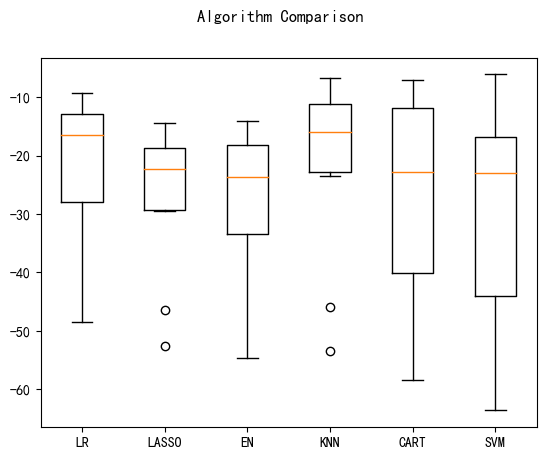

耗时(秒)： 0.6485888957977295


In [8]:
import time
start = time.time()

# 评估算法 - 正态化数据
pipelines = {}
pipelines['ScalerLR']    = Pipeline([('Scaler', StandardScaler()), ('LR', LinearRegression())])
pipelines['ScalerLASSO'] = Pipeline([('Scaler', StandardScaler()), ('LASSO', Lasso())])
pipelines['ScalerEN']    = Pipeline([('Scaler', StandardScaler()), ('EN', ElasticNet())])
pipelines['ScalerKNN']   = Pipeline([('Scaler', StandardScaler()), ('KNN', KNeighborsRegressor())])
pipelines['ScalerCART']  = Pipeline([('Scaler', StandardScaler()), ('CART', DecisionTreeRegressor())])
pipelines['ScalerSVM']   = Pipeline([('Scaler', StandardScaler()), ('SVM', SVR())])
results = []
for key in pipelines:
    kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
    cv_result = cross_val_score(pipelines[key], X_train, Y_train, cv = kfold, scoring = scoring)
    results.append(cv_result)
    print('%s: %f (%f)' % (key, cv_result.mean(), cv_result.std()))
    
#评估算法 - 箱线图
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(models.keys())
pyplot.show()

finish = time.time()
print("耗时(秒)：", finish - start)

# 单一算法：总结
数据标准化、参数调整；
单一算法最好的是knn，在n=1时最优MSE是19.4978（sklearn中取反，所以是负）

In [9]:
import time
start = time.time()

# 调参改进算法 - KNN
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
param_grid = {'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]}
model = KNeighborsRegressor()
kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
grid = GridSearchCV(estimator = model, param_grid = param_grid, scoring = scoring, cv = kfold)
grid_result = grid.fit(X = rescaledX, y = Y_train)

print('最优：%s 使用%s' % (grid_result.best_score_, grid_result.best_params_))
cv_results = zip(grid_result.cv_results_['mean_test_score'],
                 grid_result.cv_results_['std_test_score'],
                 grid_result.cv_results_['params'])
for mean, std, param in cv_results:
    print('%f (%f) with %r' % (mean, std, param))

finish = time.time()
print("耗时(秒)：", finish - start)

最优：-19.497828658536584 使用{'n_neighbors': 1}
-19.497829 (15.769847) with {'n_neighbors': 1}
-19.977984 (13.803973) with {'n_neighbors': 3}
-21.270967 (14.833544) with {'n_neighbors': 5}
-21.577292 (14.952592) with {'n_neighbors': 7}
-21.001075 (14.701297) with {'n_neighbors': 9}
-21.490306 (14.866957) with {'n_neighbors': 11}
-21.268533 (14.454969) with {'n_neighbors': 13}
-21.968092 (14.209894) with {'n_neighbors': 15}
-22.739880 (14.492752) with {'n_neighbors': 17}
-23.506901 (14.903224) with {'n_neighbors': 19}
-24.240303 (15.156565) with {'n_neighbors': 21}
耗时(秒)： 0.29372477531433105


# 集成算法
用了6个算法，其中4个提升算法，2个装袋算法

ScaledAB: -15.719611 (8.335725)
ScaledAB-KNN: -16.366759 (10.863527)
ScaledAB-LR: -24.386865 (8.842569)
ScaledRFR: -12.260297 (9.048352)
ScaledETR: -9.006570 (6.737935)
ScaledGBR: -11.045028 (8.674283)


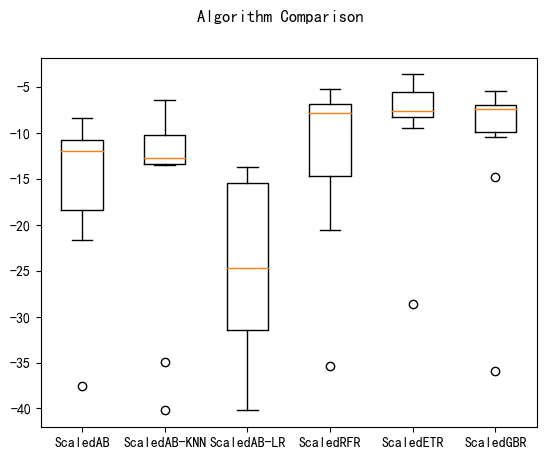

耗时(秒)： 28.06234359741211


In [10]:
import time
start = time.time()

# 集成算法
ensembles = {}
ensembles['ScaledAB']     = Pipeline([('Scaler', StandardScaler()), ('AB', AdaBoostRegressor())]) # 默认学习器是DecisionTree
ensembles['ScaledAB-KNN'] = Pipeline([('Scaler', StandardScaler()),
                                       ('ABKNN', AdaBoostRegressor(base_estimator=KNeighborsRegressor(n_neighbors = 3)))])
ensembles['ScaledAB-LR']  = Pipeline([('Scaler', StandardScaler()), ('ABLR', AdaBoostRegressor(LinearRegression()))])
ensembles['ScaledRFR']    = Pipeline([('Scaler', StandardScaler()), ('RFR', RandomForestRegressor())])
ensembles['ScaledETR']    = Pipeline([('Scaler', StandardScaler()), ('ETR', ExtraTreesRegressor())])
ensembles['ScaledGBR']    = Pipeline([('Scaler', StandardScaler()), ('GBR', GradientBoostingRegressor())])

results = []
for key in ensembles:
    kfold = KFold(n_splits = num_folds, shuffle = True, random_state=seed)
    cv_result = cross_val_score(ensembles[key], X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_result)
    print('%s: %f (%f)' % (key, cv_result.mean(), cv_result.std()))

# 集成算法 - 箱线图
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(ensembles.keys())
pyplot.show()

finish = time.time()
print("耗时(秒)：", finish - start)

# 集成算法调参：GBM算法
最优参数是900个基础学习器

In [11]:
import time
start = time.time()

# 集成算法GBM - 调参
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
param_grid = {'n_estimators': [10, 50, 100, 200, 300, 400, 500, 600, 700, 800, 900]}
model = GradientBoostingRegressor()
kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
grid = GridSearchCV(estimator = model, param_grid = param_grid, scoring = scoring, cv = kfold)
grid_result = grid.fit(X = rescaledX, y = Y_train)
print('最优：%s 使用%s' % (grid_result.best_score_, grid_result.best_params_))

finish = time.time()
print("耗时(秒)：", finish - start)

最优：-10.451875471504732 使用{'n_estimators': 900}
耗时(秒)： 195.138756275177


# 集成算法调参：ET算法
最优参数是70个基础学习器

In [12]:
import time
start = time.time()

# 集成算法ET - 调参
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
param_grid = {'n_estimators': [5, 10, 20, 30, 40, 50, 60, 70, 80]}
model = ExtraTreesRegressor()
kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
grid = GridSearchCV(estimator = model, param_grid = param_grid, scoring = scoring, cv = kfold)
grid_result = grid.fit(X = rescaledX, y = Y_train)
print('最优：%s 使用%s' % (grid_result.best_score_, grid_result.best_params_))

finish = time.time()
print("耗时(秒)：", finish - start)

最优：-9.090948396714778 使用{'n_estimators': 70}
耗时(秒)： 18.99515700340271


# 集成算法总结
GBM和ET比较，最优的是ET算法，70个基础学习器，且用时较少
注意最后用MSE，不是scoring里面用的neg_mean_squared_error

In [14]:
#训练模型
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
gbr = ExtraTreesRegressor(n_estimators = 70)
gbr.fit(X = rescaledX, y = Y_train)
# 评估算法模型
rescaledX_validation = scaler.transform(X_validation)
predictions = gbr.predict(rescaledX_validation)
print(mean_squared_error(Y_validation, predictions))

13.072268527410964
